<a href="https://colab.research.google.com/github/Alex-Casella/msds501_computation/blob/main/03_Visualizations_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Visualizations (Google Colab version)

This is the Colab-ready version of the original notebook. Run the **Setup** cells first, then run the notebook top to bottom.

## Setup

pandas, seaborn and matplotlib are preinstalled in Colab — no installs needed.

---
**Assignment:** each code cell below has been emptied and replaced with `# TODO` hints. Read the markdown above each cell, then write the code yourself. The **Setup** cells (install / upload / imports) already work — run them first.


### Upload data files

When you run the next cell a file picker appears. Select these file(s) from your computer:
- `BevZTestHistory.csv`
- `AlumniGiving_DonationHistory.csv`


In [10]:
from google.colab import files
uploaded = files.upload()  # select the file(s) listed above

import os
print("Uploaded:", sorted(uploaded.keys()))


Saving BevZTestHistory.csv to BevZTestHistory.csv
Uploaded: ['BevZTestHistory.csv']


# Visualizations

- (1D numbers) Histograms and boxplots
- subsetting with .isin()
- (1D categories) Countplot
- (2D - category vs category) compare subgroup visualizations with .groupby()
- (2D - category vs number) Catplot
- (2D - number vs number) Pairplot

In [4]:
# Data Manipulation
import pandas as pd

# Graphics
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.figsize'] = (8.0, 8.0)
                              ###(  → ,  ↑  ) ###
mpl.rcParams['font.size'] = 18

# Histograms and boxplots

## Point: Always do quick visualizations on the overall data and then do deep dives into subgroups

### Let's start with quick visualizations of numerical variables and then move onto categorical variables

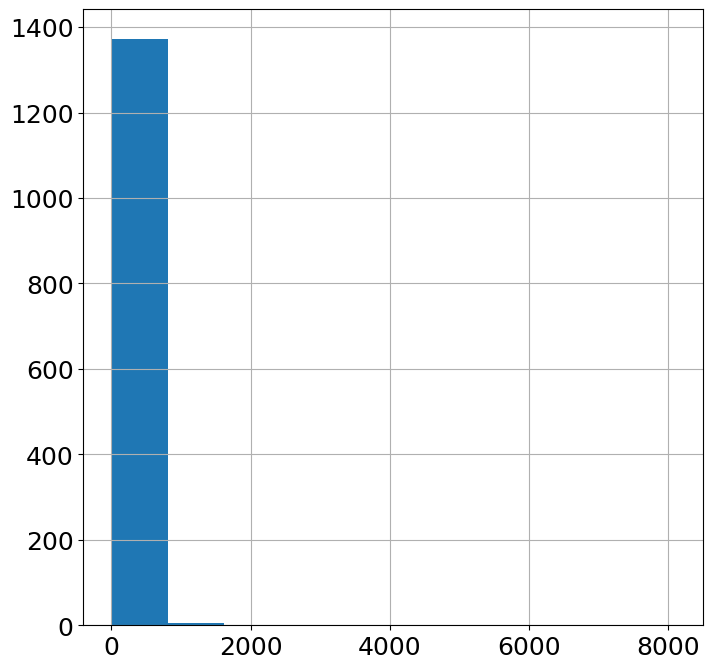

In [11]:
# TODO: Load BevZTestHistory.csv into `bev`, then plot a histogram of Units_Sold
#       (try bins=10).
# Hint: pd.read_csv(...); Series.hist(bins=...); plt.show()
bev = pd.read_csv('BevZTestHistory.csv')

bev['Units_Sold'].hist(bins=10)
plt.show()

### Based on the graphic what could be wrong with this data?

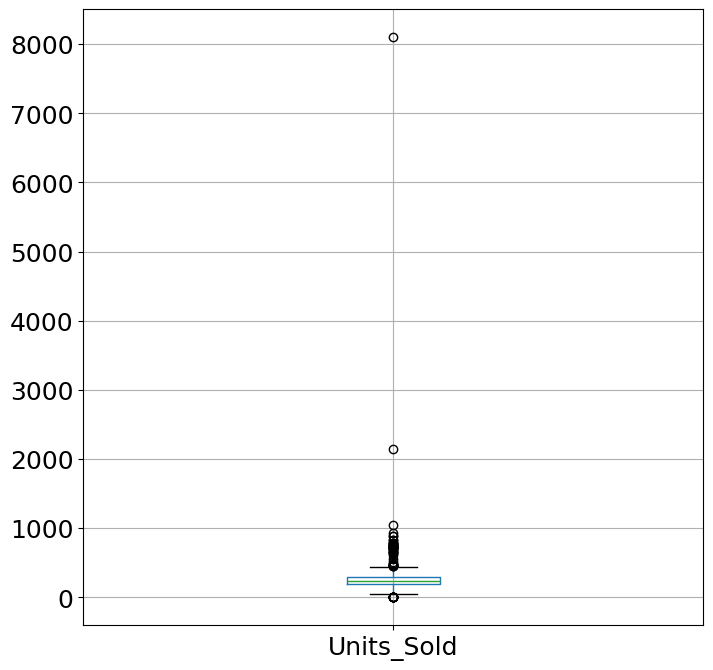

In [12]:
# TODO: Make a boxplot of Units_Sold. What does it suggest about outliers?
# Hint: bev.boxplot(column=[...]); plt.show()

bev.boxplot(column=['Units_Sold'])
plt.show()

## Notice that we have uncovered an issue with our data that we did not see in exploration nor cleaning - which is ok! Data Science is iterative and cylcical (sometimes I have to bounce back and forth between cleaning and visualizing notebooks), so we can go back and fix things or repeat steps until we get the best results.

In [13]:
# TODO: Inspect the rows where Units_Sold > 2000 (the suspicious points).
# Hint: boolean mask on bev.Units_Sold
bev[bev.Units_Sold > 2000]

,Date,Store_Name,Region,Units_Sold,Average Retail Price,Sales_Rep,Endcap,Demo
1159,9/7/20,Superior,Rocky Mountains,2140.0,$3.97,1,0,0
1243,8/10/20,Veterans,Southwest,8100.0,$4.39,0,0,0


### I would check with whoever gave me this data and confirm these points are truly accurate

<Axes: >

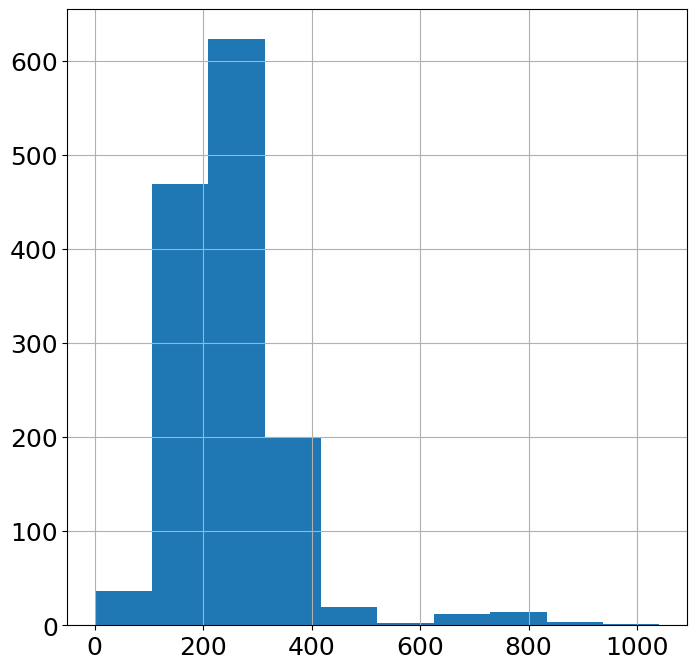

In [16]:
# TODO: Re-plot the histogram after removing the extreme Units_Sold values.
# Hint: bev[bev.Units_Sold < 2000].hist(); plt.show()

bev[bev.Units_Sold < 2000]['Units_Sold'].hist(bins = 10)

<Axes: >

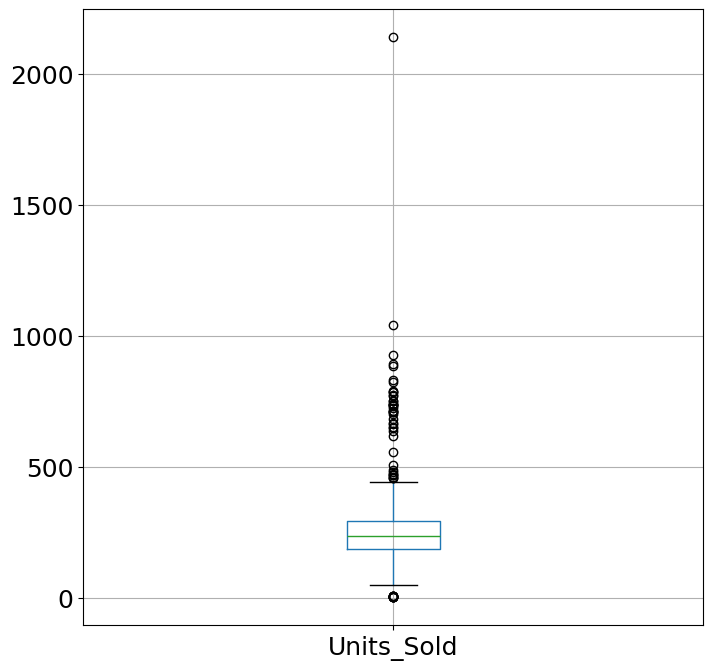

In [18]:
# TODO: Boxplot of Units_Sold after filtering out extreme values (e.g. < 8000).
# Hint: .boxplot(column=[...])

bev[bev.Units_Sold < 8000].boxplot(column=['Units_Sold'])

# .isin()

In [20]:
# TODO: Load AlumniGiving_DonationHistory.csv into df.
# Hint: pd.read_csv(...)

df = pd.read_csv('AlumniGiving_DonationHistory.csv')

In [24]:
# TODO: Create a target column DONATED = 1 if NUMBER_OF_DONATIONS > 0 else 0.
# Hint: (df["NUMBER_OF_DONATIONS"] > 0).astype(int)

df['DONATED'] = (df['NUMBER_OF_DONATIONS'] > 0).astype(int)
print(df['DONATED'])

0         0
1         1
2         1
3         0
4         1
         ..
118849    0
118850    0
118851    0
118852    0
118853    0
Name: DONATED, Length: 118854, dtype: int64


## as we learned in Exploration, CITY has high cardinality(~4000 cities total) making it hard to visualize nicely

## what should we do to make nice visuals?

- take a subset
- example: take the top n most frequent values and visualize them
- for now that will do, but there are better ways to pick

In [25]:
# TODO: Get the 5 most frequent CITY values (their index).
# Hint: df.CITY.value_counts()[:5].index

df.CITY.value_counts()[:5].index

Index(['San Francisco', 'San Jose', 'Oakland', 'Sacramento', 'Santa Rosa'], dtype='object', name='CITY')

### now subset the dataframe to only show rows if the city is a match from our list

In [ ]:
# TODO: Subset df to rows whose CITY is in the top 5, then sample 5 rows.
# Hint: df[df.CITY.isin(top_5_cities)]


In [ ]:
# TODO: Confirm the subset only contains those 5 cities.
# Hint: subset_df.CITY.value_counts()


## let's functionalize the above

In [ ]:
# TODO: Generalize the above. Pick a feature (e.g. "CITY") and n (e.g. 5),
#       find the top-n values, and show df[[ "DONATED", feature ]] for those rows.
# Hint: df[feature].value_counts()[:n].index ; df[df[feature].isin(...)]


In [ ]:
# TODO: Store that subset in a variable called `tinydf`.


## next, let's visualize the relationships between a categorical variable and another categorical variable

# Countplot

In [ ]:
# TODO: Draw a horizontal countplot of `feature` using tinydf.
# Hint: sns.countplot(data=tinydf, y=feature); plt.show()


## countplot creates a count of categorical columns automatically

## but it's biggest use is the hue argument to split CITY by DONATED

In [ ]:
# TODO: Add hue="DONATED" to the countplot to split counts by donor status.
# Hint: sns.countplot(data=tinydf, y="CITY", hue="DONATED"); plt.show()


## let's loop through 2 interesting examples

In [ ]:
# TODO: Loop over ['MI', 'MARRIED_TO_ALUM']. For each column, subset to its
#       top-5 values and draw a countplot with hue="DONATED".
#       (Fill MI's NaNs with "missing" first.)
# Hint: reuse the isin + value_counts pattern inside a for loop (try/except is fine).


## these results don't seem that useful, but is there a better way to visualize this?

## ideas?

- we've been looking at absolute numbers
- what about relative numbers?
- what about proportions?

# Groupby

In [ ]:
# TODO: For column="CITY", rebuild tinydf, then group by the column and get
#       value_counts of DONATED within each group.
# Hint: tinydf.groupby(column)["DONATED"].value_counts()


## Now we see the actual number of people in each area who give and who do not, but sometimes we want proportions instead

In [ ]:
# TODO: Repeat the groupby with normalize=True to get ratios instead of counts.
# Hint: .value_counts(normalize=True)


## it's important to note that this data type is a series

In [ ]:
# TODO: Check the type of the result (notice it is a Series).
# Hint: type(...)


In [ ]:
# TODO: For each of ['MI', 'MARRIED_TO_ALUM']:
#   - subset to the top-5 values of that column ([["DONATED", column]])
#   - groupby the column, value_counts(normalize=True)  -> a Series
#   - .unstack() it into a DataFrame
#   - plot kind="barh", stacked=True (color 1 -> green, 0 -> black)
#   - move the legend outside the plot, then plt.show()
# Hint: gb.unstack().plot(kind="barh", stacked=True, ...)


## Point: Up till now, we've only looked at unadjusted values, but groupby, normalization, and stacking gives us a picture of proportion

# Catplot

## next, let's turn our attention to categorical vs numerical columns

In [ ]:
# TODO: Load the seaborn "titanic" dataset, then make a catplot with
#       x="age", y="class".
# Hint: sns.load_dataset("titanic"); sns.catplot(data=..., x=..., y=...)


## let's add a 3rd dimension (feature) - normally not recommended but in this case, the data is small enough to easily see patterns

In [ ]:
# TODO: Add a 3rd dimension to the catplot with hue="sex".
# Hint: sns.catplot(..., hue="sex")


## now let's change the style to a bar plot

In [ ]:
# TODO: Change the catplot to a bar plot with kind="bar".
# Hint: sns.catplot(..., kind="bar")


# Pairplot

## finally, let's look at numerical vs numerical features

In [ ]:
# TODO: Load the "penguins" dataset and make a pairplot of its numeric features.
# Hint: sns.load_dataset("penguins"); sns.pairplot(...)
